In [1]:
import pandas as pd
import numpy as np
import json
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)

COLORS = ['#6366f1', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ddd6fe', '#ede9fe']
ACCENT = '#6366f1'

In [2]:
# Загрузка данных
raw_events = pd.read_csv('events_raw.csv')
raw_events['created_at'] = pd.to_datetime(raw_events['created_at'])

users = pd.read_csv('users.csv')
users_activity = pd.read_csv('users_activity.csv')
users_activity['first_event_at'] = pd.to_datetime(users_activity['first_event_at'])
users_activity['last_event_at'] = pd.to_datetime(users_activity['last_event_at'])

results = pd.read_csv('results_rows.csv')
results['created_at'] = pd.to_datetime(results['created_at'])

habits = pd.read_csv('habits_rows.csv')
habits['created_at'] = pd.to_datetime(habits['created_at'])

progress = pd.read_csv('progress_rows.csv')

events_summary = pd.read_csv('events_summary.csv')

# Парсинг params_json
raw_events['params'] = raw_events['params_json'].apply(lambda x: json.loads(x) if pd.notna(x) else {})

print(f"Всего событий: {len(raw_events)}")
print(f"Уникальных пользователей (события): {raw_events['user_id'].nunique()}")
print(f"Зарегистрированных пользователей: {len(users)}")
print(f"Период: {raw_events['created_at'].min().date()} — {raw_events['created_at'].max().date()}")
print(f"\nТипы событий ({raw_events['event'].nunique()}):")
print(raw_events['event'].value_counts().to_string())

Всего событий: 1171
Уникальных пользователей (события): 57
Зарегистрированных пользователей: 9
Период: 2026-03-19 — 2026-03-26

Типы событий (20):
event
page_view                              530
quiz_answer                            311
quiz_start                              58
result_view                             38
dashboard_view                          35
quiz_complete                           33
recommendations_view                    31
habit_toggle                            28
recommendations_open_from_result        22
tracker_view                            17
sign_in_success                         10
habit_add                               10
sign_up_error                            9
dashboard_open                           8
sign_up_success                          7
recommendations_open_from_dashboard      7
feedback_submit                          5
pdf_export                               5
sign_in_error                            4
habit_delete                  

## 1. Воронка конверсии

Основной флоу: **Главная → Квиз → Результат → Рекомендации → Регистрация → Трекер привычек**

Sign-up происходит после просмотра рекомендаций, но возможна точка входа и в начале.

In [3]:
# Воронка: считаем уникальных пользователей на каждом этапе
funnel_steps = [
    ('Посещение сайта', 'page_view'),
    ('Начало квиза', 'quiz_start'),
    ('Завершение квиза', 'quiz_complete'),
    ('Просмотр результата', 'result_view'),
    ('Просмотр рекомендаций', 'recommendations_view'),
    ('Регистрация', 'sign_up_success'),
    ('Трекер привычек', 'tracker_view'),
    ('Добавление привычки', 'habit_add'),
]

funnel_data = []
for label, event in funnel_steps:
    n_users = raw_events[raw_events['event'] == event]['user_id'].nunique()
    funnel_data.append({'step': label, 'users': n_users})

funnel_df = pd.DataFrame(funnel_data)
funnel_df['pct_total'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['pct_prev'] = [100.0] + (funnel_df['users'].iloc[1:].values / funnel_df['users'].iloc[:-1].values * 100).round(1).tolist()

fig = go.Figure(go.Funnel(
    y=funnel_df['step'],
    x=funnel_df['users'],
    textinfo='value+percent previous',
    textposition='inside',
    marker=dict(
        color=['#6366f1', '#7c3aed', '#8b5cf6', '#a78bfa', '#c084fc', '#d946ef', '#f472b6', '#fb7185'],
    ),
    connector=dict(line=dict(color='#e2e8f0', width=1)),
))

fig.update_layout(
    title=dict(text='Воронка конверсии пользователей', font=dict(size=20)),
    font=dict(size=14),
    height=500,
    width=800,
    plot_bgcolor='white',
)
fig.show()

print("\nДетализация воронки:")
print(funnel_df.to_string(index=False))


Детализация воронки:
                 step  users  pct_total  pct_prev
      Посещение сайта     57      100.0     100.0
         Начало квиза     29       50.9      50.9
     Завершение квиза     29       50.9     100.0
  Просмотр результата     29       50.9     100.0
Просмотр рекомендаций     26       45.6      89.7
          Регистрация      7       12.3      26.9
      Трекер привычек      6       10.5      85.7
  Добавление привычки      4        7.0      66.7


## 2. Санки-диаграмма переходов между событиями

Визуализация реальных путей пользователей: откуда пришли → куда пошли. Показывает альтернативные маршруты и точки выхода.

In [4]:
# Санки-диаграмма: переходы между последовательными событиями пользователя
events_sorted = raw_events.sort_values(['user_id', 'created_at']).copy()

# Убираем дублирующиеся page_view, оставляем значимые события
key_events = events_sorted[events_sorted['event'] != 'page_view'].copy()

# Добавляем следующее событие пользователя
key_events['next_event'] = key_events.groupby('user_id')['event'].shift(-1)
transitions = key_events.dropna(subset=['next_event'])

# Считаем переходы
transition_counts = transitions.groupby(['event', 'next_event']).size().reset_index(name='count')
transition_counts = transition_counts[transition_counts['count'] >= 2]  # фильтр шума

# Строим Sankey
all_events = list(set(transition_counts['event'].tolist() + transition_counts['next_event'].tolist()))
event_idx = {e: i for i, e in enumerate(all_events)}

# Красивые названия
label_map = {
    'quiz_start': 'Старт квиза',
    'quiz_answer': 'Ответ на вопрос',
    'quiz_complete': 'Квиз завершён',
    'result_view': 'Результат',
    'recommendations_view': 'Рекомендации',
    'recommendations_open_from_result': 'Рек. из результата',
    'recommendations_open_from_dashboard': 'Рек. из дашборда',
    'sign_up_success': 'Регистрация',
    'sign_up_error': 'Ошибка регистрации',
    'sign_in_success': 'Вход',
    'sign_in_error': 'Ошибка входа',
    'tracker_view': 'Трекер',
    'habit_add': 'Добавление привычки',
    'habit_toggle': 'Отметка привычки',
    'habit_delete': 'Удаление привычки',
    'dashboard_view': 'Дашборд',
    'dashboard_open': 'Открытие дашборда',
    'feedback_submit': 'Отзыв',
    'pdf_export': 'Экспорт PDF',
}

labels = [label_map.get(e, e) for e in all_events]

node_colors = []
color_map = {
    'quiz_start': '#6366f1', 'quiz_answer': '#818cf8', 'quiz_complete': '#7c3aed',
    'result_view': '#8b5cf6', 'recommendations_view': '#a78bfa',
    'recommendations_open_from_result': '#c084fc',
    'recommendations_open_from_dashboard': '#d8b4fe',
    'sign_up_success': '#22c55e', 'sign_up_error': '#ef4444',
    'sign_in_success': '#10b981', 'sign_in_error': '#f87171',
    'tracker_view': '#f59e0b', 'habit_add': '#f97316', 'habit_toggle': '#fb923c',
    'habit_delete': '#fbbf24',
    'dashboard_view': '#06b6d4', 'dashboard_open': '#22d3ee',
    'feedback_submit': '#ec4899', 'pdf_export': '#14b8a6',
}
for e in all_events:
    node_colors.append(color_map.get(e, '#94a3b8'))

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20, thickness=25,
        label=labels,
        color=node_colors,
    ),
    link=dict(
        source=[event_idx[r['event']] for _, r in transition_counts.iterrows()],
        target=[event_idx[r['next_event']] for _, r in transition_counts.iterrows()],
        value=transition_counts['count'].tolist(),
        color='rgba(99, 102, 241, 0.15)',
    ),
))

fig.update_layout(
    title=dict(text='Потоки переходов между событиями', font=dict(size=20)),
    font=dict(size=13),
    height=600, width=1000,
)
fig.show()

## 3. Когортный анализ удержания (Retention)

Группируем пользователей по дню первого визита. Считаем, сколько из них вернулись на Day 1, Day 2 и т.д.

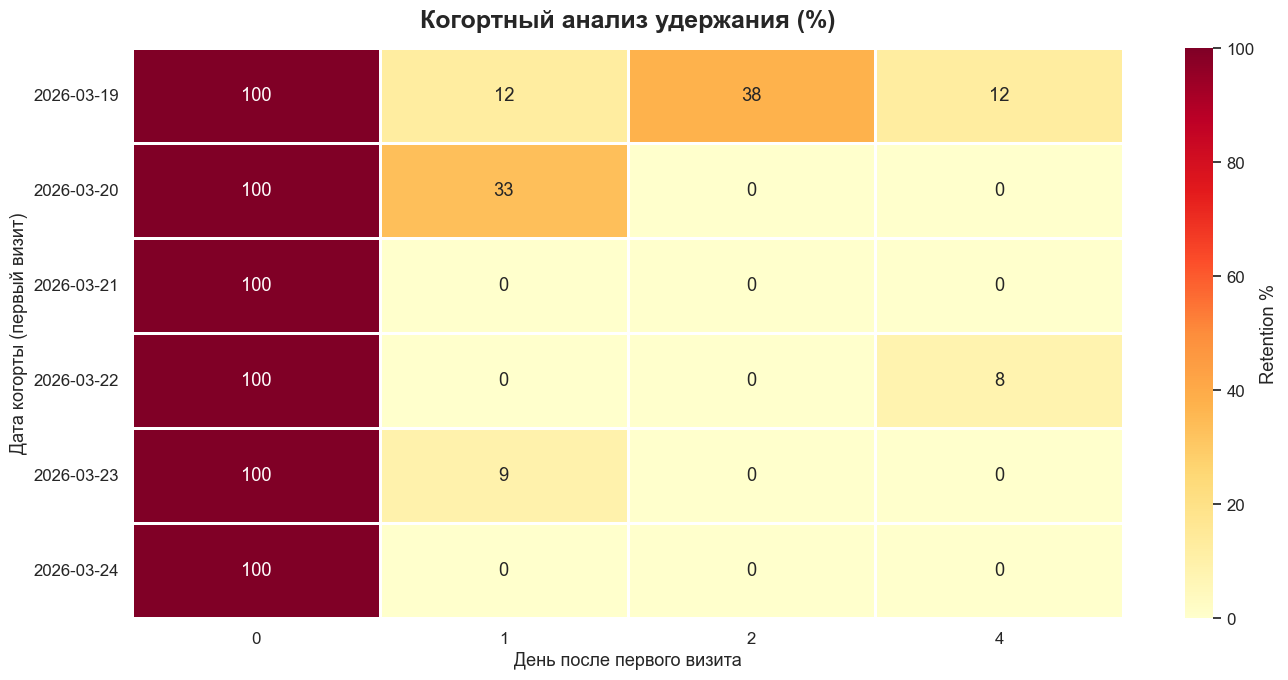

Средний retention по дням:
  Day 0: 100.0%
  Day 1: 9.2%
  Day 2: 6.2%
  Day 4: 3.5%


In [5]:
# Когортный retention
events_with_date = raw_events.copy()
events_with_date['date'] = events_with_date['created_at'].dt.date

# Первый визит каждого пользователя
first_visit = events_with_date.groupby('user_id')['date'].min().reset_index()
first_visit.columns = ['user_id', 'cohort_date']

# Объединяем
events_cohort = events_with_date.merge(first_visit, on='user_id')
events_cohort['day_n'] = (pd.to_datetime(events_cohort['date']) - pd.to_datetime(events_cohort['cohort_date'])).dt.days

# Строим retention-матрицу
cohort_sizes = events_cohort.groupby('cohort_date')['user_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort_date', 'cohort_size']

retention_raw = events_cohort.groupby(['cohort_date', 'day_n'])['user_id'].nunique().reset_index()
retention_raw.columns = ['cohort_date', 'day_n', 'users']
retention_raw = retention_raw.merge(cohort_sizes, on='cohort_date')
retention_raw['retention'] = (retention_raw['users'] / retention_raw['cohort_size'] * 100).round(1)

# Pivot для heatmap
retention_pivot = retention_raw.pivot(index='cohort_date', columns='day_n', values='retention').fillna(0)
# Ограничиваем до 7 дней
retention_pivot = retention_pivot[[c for c in retention_pivot.columns if c <= 7]]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    retention_pivot,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Retention %'},
    ax=ax,
)
ax.set_title('Когортный анализ удержания (%)', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('День после первого визита', fontsize=13)
ax.set_ylabel('Дата когорты (первый визит)', fontsize=13)
ax.set_yticklabels([str(d) for d in retention_pivot.index], rotation=0)
plt.tight_layout()
plt.show()

# Средний retention по дням
avg_retention = retention_pivot.mean().round(1)
print("Средний retention по дням:")
for day, val in avg_retention.items():
    print(f"  Day {day}: {val}%")

## 4. Анализ квиза

- Распределение баллов (violin plot)
- Heatmap ответов по вопросам
- Связь балла квиза с дальнейшей вовлечённостью

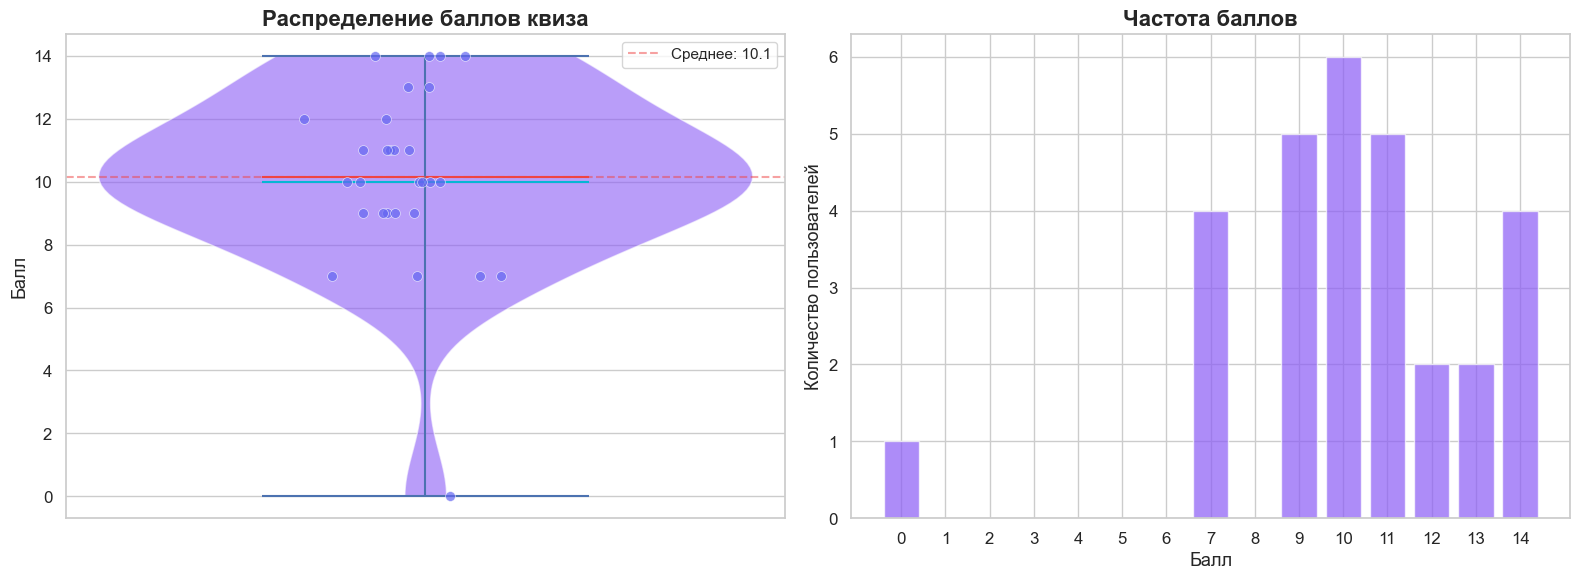

Статистика баллов: среднее=10.1, медиана=10.0, мин=0, макс=14


In [6]:
# 4a. Распределение баллов квиза (violin + strip)
quiz_scores = raw_events[raw_events['event'] == 'quiz_complete'].copy()
quiz_scores['score'] = quiz_scores['params'].apply(lambda x: x.get('score', None))
quiz_scores = quiz_scores.dropna(subset=['score'])
quiz_scores['score'] = quiz_scores['score'].astype(int)

# Берём последний результат каждого пользователя
last_scores = quiz_scores.sort_values('created_at').groupby('user_id').last().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot
parts = axes[0].violinplot(last_scores['score'], positions=[0], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#8b5cf6')
    pc.set_alpha(0.6)
parts['cmeans'].set_color('#ef4444')
parts['cmedians'].set_color('#06b6d4')

# Добавляем точки
axes[0].scatter(
    np.random.normal(0, 0.04, len(last_scores)),
    last_scores['score'],
    color='#6366f1', alpha=0.7, s=50, zorder=5, edgecolors='white', linewidth=0.5
)
axes[0].set_title('Распределение баллов квиза', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Балл', fontsize=13)
axes[0].set_xticks([])
axes[0].axhline(y=last_scores['score'].mean(), color='#ef4444', linestyle='--', alpha=0.5, label=f"Среднее: {last_scores['score'].mean():.1f}")
axes[0].legend(fontsize=11)

# Гистограмма с KDE-подобным эффектом
score_counts = last_scores['score'].value_counts().sort_index()
axes[1].bar(score_counts.index, score_counts.values, color='#8b5cf6', alpha=0.7, edgecolor='white', width=0.8)
axes[1].set_title('Частота баллов', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Балл', fontsize=13)
axes[1].set_ylabel('Количество пользователей', fontsize=13)
axes[1].set_xticks(range(0, 15))

plt.tight_layout()
plt.show()

print(f"Статистика баллов: среднее={last_scores['score'].mean():.1f}, медиана={last_scores['score'].median():.1f}, "
      f"мин={last_scores['score'].min()}, макс={last_scores['score'].max()}")

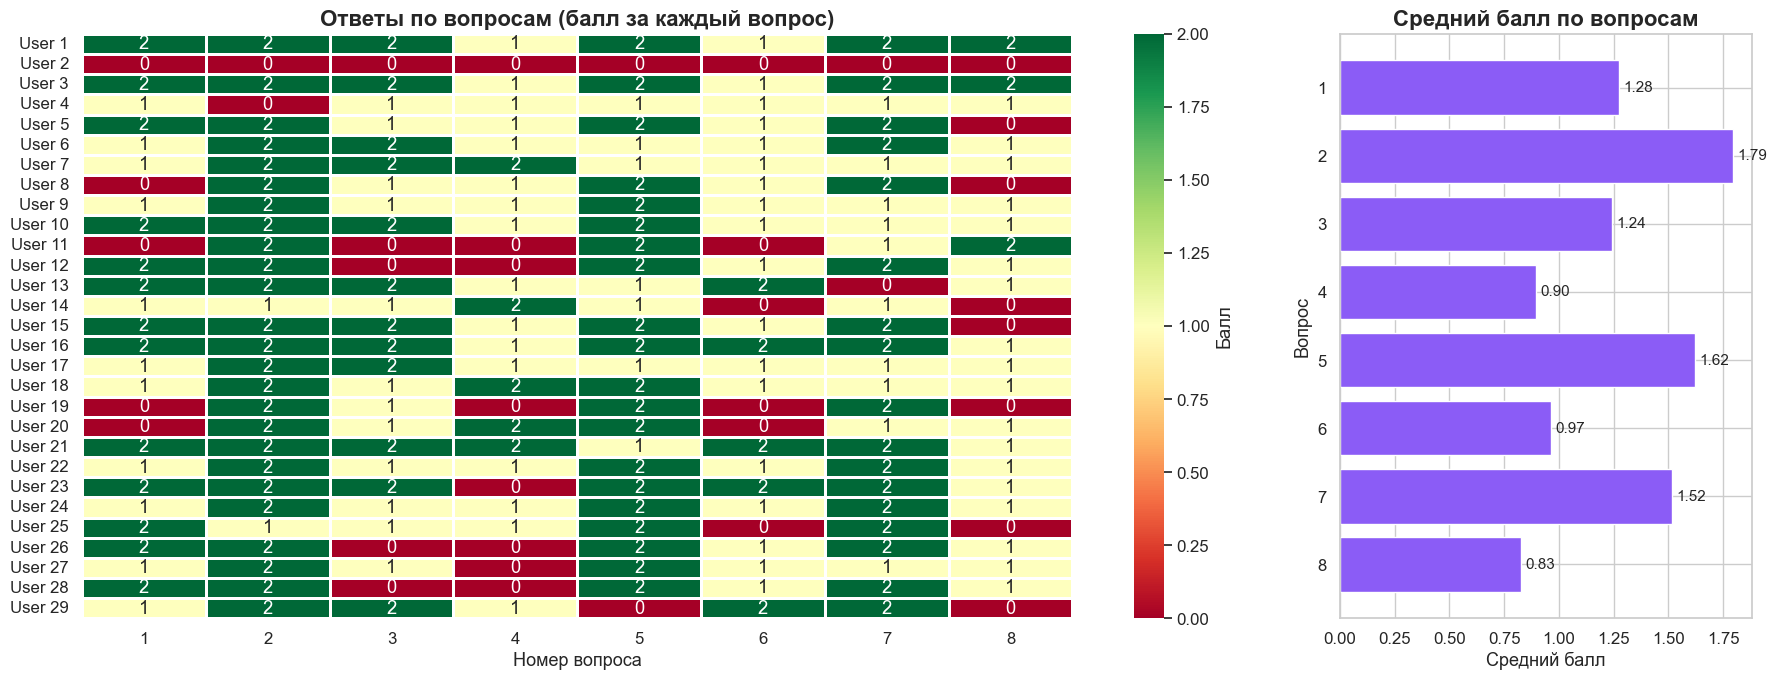

Самый сложный вопрос: 8 (средний балл: 0.83)
Самый лёгкий вопрос: 2 (средний балл: 1.79)


In [7]:
# 4b. Heatmap ответов по вопросам
quiz_answers = raw_events[raw_events['event'] == 'quiz_answer'].copy()
quiz_answers['question'] = quiz_answers['params'].apply(lambda x: x.get('question', None))
quiz_answers['score'] = quiz_answers['params'].apply(lambda x: x.get('score', None))
quiz_answers = quiz_answers.dropna(subset=['question', 'score'])

# Дедупликация: один ответ на вопрос от пользователя (последний)
quiz_answers = quiz_answers.sort_values('created_at').groupby(['user_id', 'question']).last().reset_index()

# Средний балл по вопросам
avg_by_q = quiz_answers.groupby('question')['score'].agg(['mean', 'count']).reset_index()
avg_by_q.columns = ['question', 'avg_score', 'n_answers']

# Матрица "пользователь × вопрос" для heatmap
answer_matrix = quiz_answers.pivot_table(index='user_id', columns='question', values='score', aggfunc='first')

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [3, 1]})

# Heatmap ответов
sns.heatmap(
    answer_matrix, annot=True, fmt='.0f', cmap='RdYlGn',
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Балл'},
    ax=axes[0], vmin=0, vmax=2,
    yticklabels=[f'User {i+1}' for i in range(len(answer_matrix))],
)
axes[0].set_title('Ответы по вопросам (балл за каждый вопрос)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Номер вопроса', fontsize=13)
axes[0].set_ylabel('')

# Средний балл по вопросам — горизонтальный bar chart
bars = axes[1].barh(avg_by_q['question'].astype(int), avg_by_q['avg_score'], color='#8b5cf6', edgecolor='white')
axes[1].set_xlabel('Средний балл', fontsize=13)
axes[1].set_ylabel('Вопрос', fontsize=13)
axes[1].set_title('Средний балл по вопросам', fontsize=16, fontweight='bold')
axes[1].set_yticks(avg_by_q['question'].astype(int))
axes[1].invert_yaxis()

# Аннотация — какие вопросы самые сложные
for bar, val in zip(bars, avg_by_q['avg_score']):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print("Самый сложный вопрос:", int(avg_by_q.loc[avg_by_q['avg_score'].idxmin(), 'question']),
      f"(средний балл: {avg_by_q['avg_score'].min():.2f})")
print("Самый лёгкий вопрос:", int(avg_by_q.loc[avg_by_q['avg_score'].idxmax(), 'question']),
      f"(средний балл: {avg_by_q['avg_score'].max():.2f})")

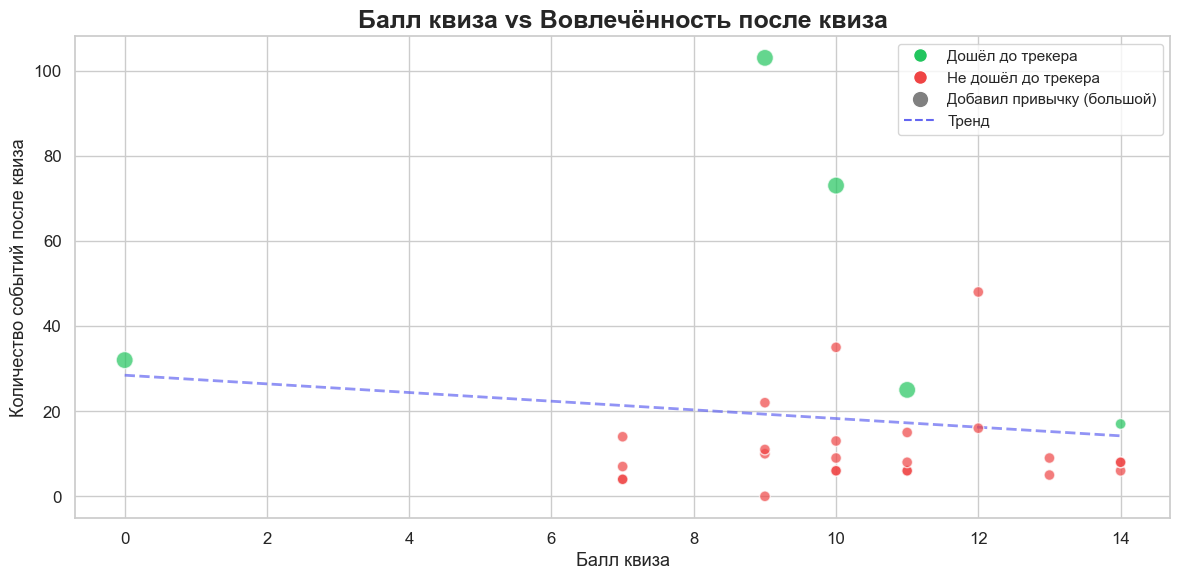

Корреляция балла и пост-квиз активности: -0.132
Дошли до трекера: 5 из 29 (17%)
Добавили привычку: 4 из 29 (14%)


In [8]:
# 4c. Связь балла квиза с дальнейшей вовлечённостью
# Для каждого пользователя: балл квиза vs количество событий после квиза
quiz_complete_events = raw_events[raw_events['event'] == 'quiz_complete'].sort_values('created_at').groupby('user_id').first().reset_index()
quiz_complete_events['score'] = quiz_complete_events['params'].apply(lambda x: x.get('score', 0))

engagement = []
for _, row in quiz_complete_events.iterrows():
    uid = row['user_id']
    quiz_time = row['created_at']
    post_quiz = raw_events[(raw_events['user_id'] == uid) & (raw_events['created_at'] > quiz_time)]
    engagement.append({
        'user_id': uid,
        'score': row['score'],
        'post_quiz_events': len(post_quiz),
        'reached_tracker': 'tracker_view' in post_quiz['event'].values,
        'added_habit': 'habit_add' in post_quiz['event'].values,
    })

engagement_df = pd.DataFrame(engagement)

fig, ax = plt.subplots(figsize=(12, 6))

scatter_colors = engagement_df['reached_tracker'].map({True: '#22c55e', False: '#ef4444'})
scatter_markers = engagement_df['added_habit'].map({True: 150, False: 60})

ax.scatter(
    engagement_df['score'], engagement_df['post_quiz_events'],
    c=scatter_colors, s=scatter_markers, alpha=0.7,
    edgecolors='white', linewidth=1, zorder=5,
)

# Трендовая линия
z = np.polyfit(engagement_df['score'], engagement_df['post_quiz_events'], 1)
p = np.poly1d(z)
x_line = np.linspace(engagement_df['score'].min(), engagement_df['score'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#6366f1', alpha=0.7, linewidth=2, label='Тренд')

ax.set_title('Балл квиза vs Вовлечённость после квиза', fontsize=18, fontweight='bold')
ax.set_xlabel('Балл квиза', fontsize=13)
ax.set_ylabel('Количество событий после квиза', fontsize=13)

# Легенда
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#22c55e', markersize=10, label='Дошёл до трекера'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444', markersize=10, label='Не дошёл до трекера'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12, label='Добавил привычку (большой)'),
    Line2D([0], [0], linestyle='--', color='#6366f1', label='Тренд'),
]
ax.legend(handles=legend_elements, fontsize=11)
plt.tight_layout()
plt.show()

corr = engagement_df['score'].corr(engagement_df['post_quiz_events'])
print(f"Корреляция балла и пост-квиз активности: {corr:.3f}")
print(f"Дошли до трекера: {engagement_df['reached_tracker'].sum()} из {len(engagement_df)} ({engagement_df['reached_tracker'].mean()*100:.0f}%)")
print(f"Добавили привычку: {engagement_df['added_habit'].sum()} из {len(engagement_df)} ({engagement_df['added_habit'].mean()*100:.0f}%)")

## 5. Сегментация пользователей

Кластеризация по поведенческим паттернам: глубина прохождения воронки, количество событий, возвраты.

In [9]:
# Профиль каждого пользователя
user_profiles = []
for uid in raw_events['user_id'].unique():
    user_events = raw_events[raw_events['user_id'] == uid]
    event_set = set(user_events['event'])
    
    # Глубина воронки (0-7)
    funnel_events = ['page_view', 'quiz_start', 'quiz_complete', 'result_view',
                     'recommendations_view', 'sign_up_success', 'tracker_view', 'habit_add']
    depth = sum(1 for e in funnel_events if e in event_set)
    
    # Количество уникальных дней
    n_days = user_events['created_at'].dt.date.nunique()
    
    user_profiles.append({
        'user_id': uid,
        'total_events': len(user_events),
        'funnel_depth': depth,
        'n_days': n_days,
        'took_quiz': 'quiz_complete' in event_set,
        'signed_up': 'sign_up_success' in event_set,
        'used_tracker': 'tracker_view' in event_set,
        'n_event_types': user_events['event'].nunique(),
    })

profiles_df = pd.DataFrame(user_profiles)

# Сегменты на основе поведения
def assign_segment(row):
    if row['used_tracker']:
        return 'Power User'
    elif row['signed_up']:
        return 'Зарегистрированный'
    elif row['took_quiz']:
        return 'Прошёл квиз'
    elif row['total_events'] > 1:
        return 'Исследователь'
    else:
        return 'Bounce'

profiles_df['segment'] = profiles_df.apply(assign_segment, axis=1)

# Radar chart по сегментам
segment_stats = profiles_df.groupby('segment').agg({
    'total_events': 'mean',
    'funnel_depth': 'mean',
    'n_days': 'mean',
    'n_event_types': 'mean',
}).reset_index()

# Нормализация для radar chart (0-1)
metrics = ['total_events', 'funnel_depth', 'n_days', 'n_event_types']
metric_labels = ['События', 'Глубина воронки', 'Дни активности', 'Типы событий']

for m in metrics:
    max_val = segment_stats[m].max()
    segment_stats[f'{m}_norm'] = segment_stats[m] / max_val if max_val > 0 else 0

fig = go.Figure()

segment_colors = {
    'Power User': '#6366f1',
    'Зарегистрированный': '#8b5cf6',
    'Прошёл квиз': '#a78bfa',
    'Исследователь': '#06b6d4',
    'Bounce': '#94a3b8',
}

for _, row in segment_stats.iterrows():
    values = [row[f'{m}_norm'] for m in metrics]
    values.append(values[0])  # замыкаем
    
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=metric_labels + [metric_labels[0]],
        fill='toself',
        name=f"{row['segment']} (n={len(profiles_df[profiles_df['segment']==row['segment']])})",
        line=dict(color=segment_colors.get(row['segment'], '#94a3b8')),
        opacity=0.6,
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=dict(text='Поведенческие профили сегментов пользователей', font=dict(size=20)),
    font=dict(size=13),
    height=550, width=700,
    showlegend=True,
)
fig.show()

# Пирог сегментов
segment_counts = profiles_df['segment'].value_counts()
fig2 = go.Figure(go.Pie(
    labels=segment_counts.index,
    values=segment_counts.values,
    hole=0.4,
    marker=dict(colors=[segment_colors.get(s, '#94a3b8') for s in segment_counts.index]),
    textinfo='label+percent',
    textfont=dict(size=13),
))
fig2.update_layout(
    title=dict(text='Распределение сегментов пользователей', font=dict(size=20)),
    height=450, width=600,
)
fig2.show()

print("\nСегменты:")
for seg in segment_counts.index:
    n = segment_counts[seg]
    pct = n / len(profiles_df) * 100
    print(f"  {seg}: {n} ({pct:.0f}%)")


Сегменты:
  Bounce: 23 (40%)
  Прошёл квиз: 19 (33%)
  Зарегистрированный: 7 (12%)
  Power User: 6 (11%)
  Исследователь: 2 (4%)


## 6. Активность во времени

- Stacked area chart — события по дням в разбивке по типам
- Heatmap «день недели x час» — когда пользователи наиболее активны

In [10]:
# 6a. Stacked area chart — события по дням
raw_events['date'] = raw_events['created_at'].dt.date

# Группируем по основным категориям
def categorize_event(event):
    if 'quiz' in event:
        return 'Квиз'
    elif 'sign' in event:
        return 'Авторизация'
    elif 'habit' in event or 'tracker' in event:
        return 'Трекер привычек'
    elif 'recommendation' in event:
        return 'Рекомендации'
    elif event in ('dashboard_view', 'dashboard_open'):
        return 'Дашборд'
    elif event == 'page_view':
        return 'Просмотр страниц'
    else:
        return 'Другое'

raw_events['category'] = raw_events['event'].apply(categorize_event)

daily_cats = raw_events.groupby(['date', 'category']).size().reset_index(name='count')
daily_pivot = daily_cats.pivot(index='date', columns='category', values='count').fillna(0)

cat_colors = {
    'Просмотр страниц': '#94a3b8',
    'Квиз': '#6366f1',
    'Авторизация': '#22c55e',
    'Рекомендации': '#a78bfa',
    'Трекер привычек': '#f59e0b',
    'Дашборд': '#06b6d4',
    'Другое': '#e2e8f0',
}

fig = go.Figure()
for cat in daily_pivot.columns:
    fig.add_trace(go.Scatter(
        x=daily_pivot.index, y=daily_pivot[cat],
        mode='lines', stackgroup='one',
        name=cat,
        line=dict(color=cat_colors.get(cat, '#94a3b8'), width=0.5),
    ))

fig.update_layout(
    title=dict(text='Активность по дням (stacked area)', font=dict(size=20)),
    xaxis_title='Дата', yaxis_title='Количество событий',
    font=dict(size=13),
    height=450, width=900,
    legend=dict(orientation='h', yanchor='bottom', y=-0.25),
)
fig.show()

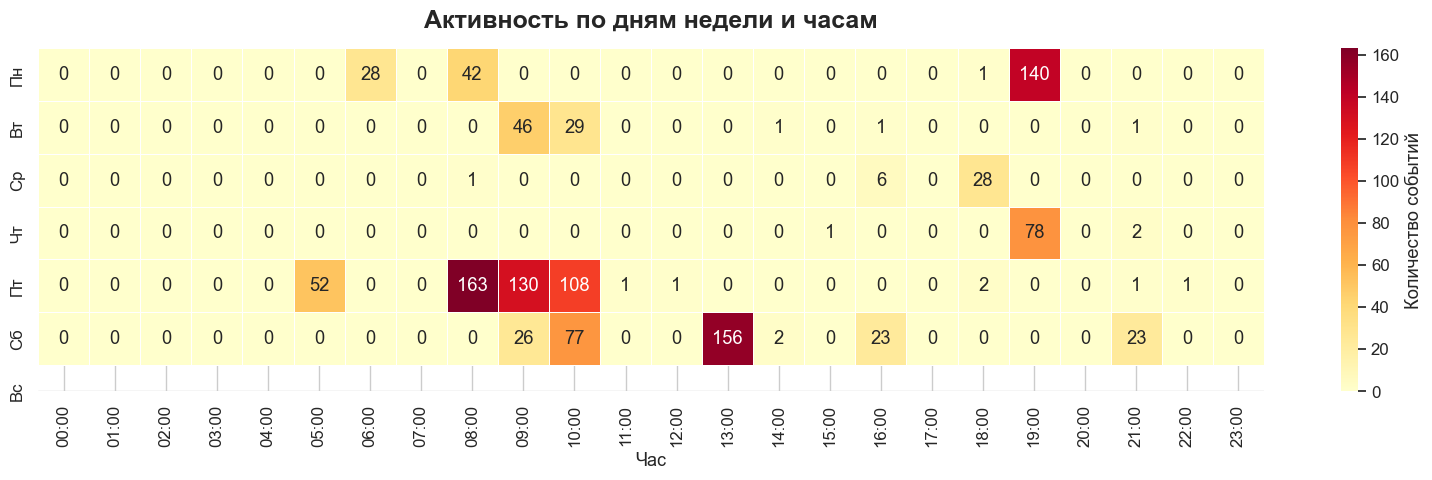

In [11]:
# 6b. Heatmap «день недели × час»
raw_events['hour'] = raw_events['created_at'].dt.hour
raw_events['weekday'] = raw_events['created_at'].dt.dayofweek

weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

heatmap_data = raw_events.groupby(['weekday', 'hour']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='weekday', columns='hour', values='count').fillna(0)

# Заполняем пропущенные часы
for h in range(24):
    if h not in heatmap_pivot.columns:
        heatmap_pivot[h] = 0
heatmap_pivot = heatmap_pivot[sorted(heatmap_pivot.columns)]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_pivot, annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5, linecolor='white',
    xticklabels=[f'{h:02d}:00' for h in range(24)],
    yticklabels=weekday_names,
    cbar_kws={'label': 'Количество событий'},
    ax=ax,
)
ax.set_title('Активность по дням недели и часам', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Час', fontsize=13)
ax.set_ylabel('', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Трекер привычек — анализ приверженности

- Процент выполнения по каждой привычке
- Heatmap активности трекинга по дням
- Динамика трекинга привычек

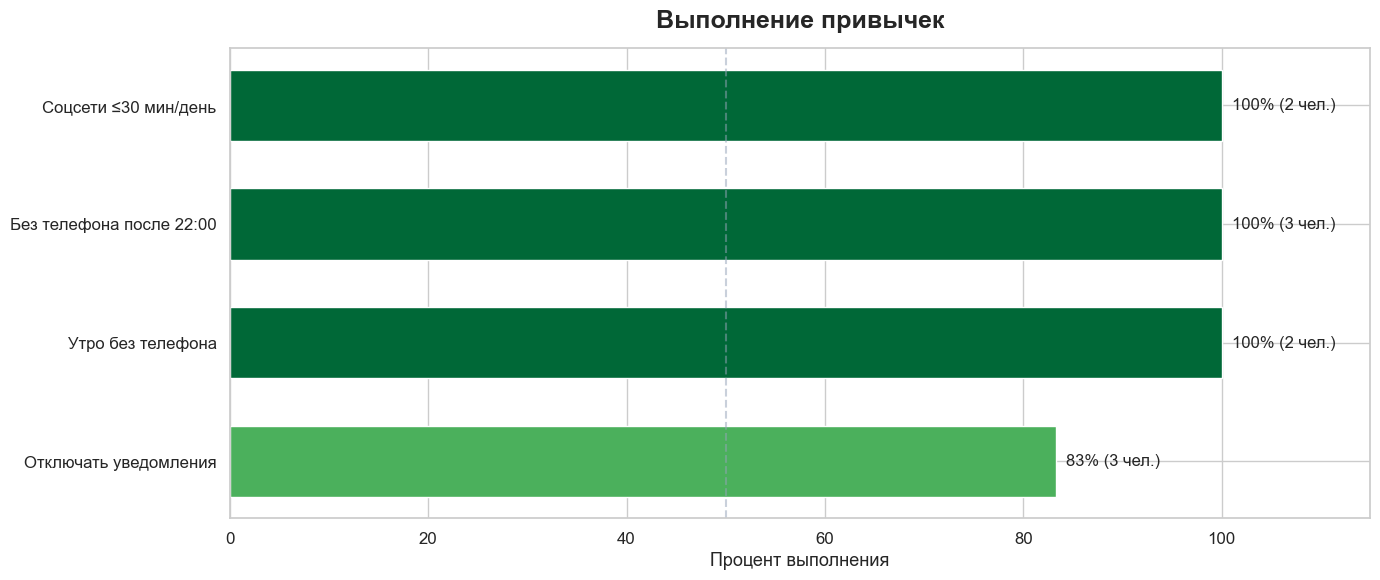

In [12]:
# 7a. Процент выполнения по привычкам
progress['value_bool'] = progress['value'].astype(str).str.lower() == 'true'

# Фильтруем тестовые привычки
real_habits = progress[~progress['habit'].isin(['test2', '905295094204', 'Мяу'])]

habit_completion = real_habits.groupby('habit').agg(
    total=('value_bool', 'count'),
    completed=('value_bool', 'sum'),
    n_users=('user_id', 'nunique'),
).reset_index()
habit_completion['pct'] = (habit_completion['completed'] / habit_completion['total'] * 100).round(1)
habit_completion = habit_completion.sort_values('pct', ascending=True)

# Горизонтальный bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Короткие названия для оси
short_names = {
    'Отключать уведомления во время фокусной работы': 'Отключать уведомления',
    'Начинать утро без телефона': 'Утро без телефона',
    'Не брать телефон в руки после 22:00': 'Без телефона после 22:00',
    'Ограничивать соцсети до 30 минут в день': 'Соцсети ≤30 мин/день',
    'Удалить все соцсети': 'Удалить соцсети',
}

labels = [short_names.get(h, h) for h in habit_completion['habit']]
colors = plt.cm.RdYlGn(habit_completion['pct'] / 100)

bars = ax.barh(labels, habit_completion['pct'], color=colors, edgecolor='white', height=0.6)

for bar, pct, n in zip(bars, habit_completion['pct'], habit_completion['n_users']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}% ({n} чел.)', va='center', fontsize=12)

ax.set_xlabel('Процент выполнения', fontsize=13)
ax.set_title('Выполнение привычек', fontsize=18, fontweight='bold', pad=15)
ax.set_xlim(0, 115)
ax.axvline(x=50, color='#94a3b8', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 7b. Heatmap трекинга привычек по пользователям и дням
real_habits_progress = real_habits.copy()

# date читается как float (12.03), форматируем обратно в строку DD.MM
date_str = real_habits_progress['date'].apply(lambda x: f"{x:.2f}" if isinstance(x, float) else str(x))
real_habits_progress['date_parsed'] = pd.to_datetime(date_str + '.2026', format='%d.%m.%Y')

user_day_counts = real_habits_progress[real_habits_progress['value_bool']].groupby(
    ['user_id', 'date_parsed']
).size().reset_index(name='habits_done')

# Пользователям даём номера
user_ids_tracker = sorted(user_day_counts['user_id'].unique())
user_labels = {uid: f'User {i+1}' for i, uid in enumerate(user_ids_tracker)}
user_day_counts['user_label'] = user_day_counts['user_id'].map(user_labels)

tracker_pivot = user_day_counts.pivot(index='user_label', columns='date_parsed', values='habits_done').fillna(0)
tracker_pivot.columns = [d.strftime('%d.%m') for d in tracker_pivot.columns]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    tracker_pivot, annot=True, fmt='.0f',
    cmap='Greens', linewidths=1, linecolor='white',
    cbar_kws={'label': 'Привычек отмечено'},
    ax=ax,
)
ax.set_title('Активность трекинга привычек по дням', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Дата', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Статистика
total_users_tracking = real_habits_progress['user_id'].nunique()
total_checks = real_habits_progress['value_bool'].sum()
print(f"Пользователей с трекингом: {total_users_tracking}")
print(f"Всего отметок привычек: {int(total_checks)}")
print(f"Среднее отметок на пользователя: {total_checks/total_users_tracking:.1f}")

## 8. Анализ авторизации

Соотношение успешных и неуспешных попыток входа и регистрации.

In [ ]:
# 8. Donut charts — авторизация
auth_events = raw_events[raw_events['event'].str.contains('sign')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sign Up
signup = auth_events[auth_events['event'].str.contains('sign_up')]
signup_counts = signup['event'].value_counts()
colors_signup = ['#22c55e', '#ef4444']
axes[0].pie(
    signup_counts.values,
    labels=['Успешно' if 'success' in l else 'Ошибка' for l in signup_counts.index],
    autopct='%1.0f%%', startangle=90,
    colors=colors_signup,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=14),
)
axes[0].set_title(f'Регистрация (n={signup_counts.sum()})', fontsize=16, fontweight='bold')

# Sign In
signin = auth_events[auth_events['event'].str.contains('sign_in')]
signin_counts = signin['event'].value_counts()
colors_signin = ['#10b981', '#f87171']
axes[1].pie(
    signin_counts.values,
    labels=['Успешно' if 'success' in l else 'Ошибка' for l in signin_counts.index],
    autopct='%1.0f%%', startangle=90,
    colors=colors_signin,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=14),
)
axes[1].set_title(f'Вход (n={signin_counts.sum()})', fontsize=16, fontweight='bold')

plt.suptitle('Успешность авторизации', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Детали
for evt in ['sign_up_success', 'sign_up_error', 'sign_in_success', 'sign_in_error']:
    n = len(auth_events[auth_events['event'] == evt])
    u = auth_events[auth_events['event'] == evt]['user_id'].nunique()
    print(f"  {evt}: {n} событий, {u} пользователей")

## 9. Сводка — ключевые метрики и выводы

In [ ]:
# Сводная таблица ключевых метрик
summary_data = {
    'Метрика': [
        'Всего уникальных посетителей',
        'Начали квиз',
        'Завершили квиз',
        'Зарегистрировались',
        'Используют трекер',
        'Конверсия: визит → квиз',
        'Конверсия: квиз → регистрация',
        'Конверсия: регистрация → трекер',
        'Конверсия: визит → трекер (сквозная)',
        'Средний балл квиза',
        'Средний retention Day 1',
    ],
    'Значение': [
        f"{raw_events['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='quiz_start']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='quiz_complete']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='sign_up_success']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='tracker_view']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='quiz_start']['user_id'].nunique() / raw_events['user_id'].nunique() * 100:.0f}%",
        f"{raw_events[raw_events['event']=='sign_up_success']['user_id'].nunique() / max(raw_events[raw_events['event']=='quiz_complete']['user_id'].nunique(), 1) * 100:.0f}%",
        f"{raw_events[raw_events['event']=='tracker_view']['user_id'].nunique() / max(raw_events[raw_events['event']=='sign_up_success']['user_id'].nunique(), 1) * 100:.0f}%",
        f"{raw_events[raw_events['event']=='tracker_view']['user_id'].nunique() / raw_events['user_id'].nunique() * 100:.0f}%",
        f"{last_scores['score'].mean():.1f} из 14",
        f"{avg_retention.get(1, 0):.0f}%",
    ]
}

summary_df = pd.DataFrame(summary_data)

# Визуализация как styled table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Стилизация заголовков
for j in range(2):
    table[0, j].set_facecolor('#6366f1')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Чередование строк
for i in range(1, len(summary_df) + 1):
    color = '#f8fafc' if i % 2 == 0 else 'white'
    for j in range(2):
        table[i, j].set_facecolor(color)

ax.set_title('Ключевые метрики Digital Focus', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()